In [1]:
# import libraries
import pandas as pd
from textblob import TextBlob
import nltk
import os

In [2]:
# load corpus
mp_corpus = pd.read_csv('manifesto_texts.csv')

In [3]:
mp_corpus.head()

,text,party,date,manifesto_id,language
0,VALMANIFEST Huvuduppgifterna i höstens val är...,11220,196009,11220_196009,swedish
1,Utdrag ur valtidningen AVGÖRANDET INFÖR 60-TA...,11320,196009,11320_196009,swedish
2,MÖJLIGHETERNAS ÅRTIONDE Sextiotalet är möjli...,11420,196009,11420_196009,swedish
3,Utdrag ur valbroschyren: HÖGERALTERNATIVET - ...,11620,196009,11620_196009,swedish
4,CENTERPARTIETS Valprogram inför valet den 18 ...,11810,196009,11810_196009,swedish


In [4]:
# check for unique text
mp_corpus["text"].nunique()

3280

In [5]:
len(mp_corpus)

3327

In [6]:
# filter to just the english texts (so we can do sentiment analysis)
mp_english = mp_corpus[mp_corpus['language'] == 'english']
print(len(mp_english)) # 495 texts
print(len(mp_english['party'].unique())) # 91 parties

495
91


## Sentiment analysis that's pre-built in TextBlob

In [7]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('brown')
nltk.download('stopwords')

blob = TextBlob(str(mp_english["text"].iloc[0]))

print("Words:", blob.words[:10])          
print("Sentences:", blob.sentences[:3])    
print("Bigrams:", blob.ngrams(n=2)[:5])    
print("Tags:", blob.tags[:10])             
print("Lowercase:", blob.lower()[:100])   
print("Noun phrases:", blob.noun_phrases[:10])     

Words: ['François', 'Mitterand', "'s", '110', 'Propositions', 'for', 'France', '1', 'Peace', 'France']
Sentences: [Sentence("François Mitterand's 110 Propositions for France."), Sentence("1."), Sentence("Peace: France open to the world.")]
Bigrams: [WordList(['François', 'Mitterand']), WordList(['Mitterand', "'s"]), WordList(["'s", '110']), WordList(['110', 'Propositions']), WordList(['Propositions', 'for'])]
Tags: [('François', 'NNP'), ('Mitterand', 'NNP'), ("'s", 'POS'), ('110', 'CD'), ('Propositions', 'NNS'), ('for', 'IN'), ('France', 'NNP'), ('1', 'CD'), ('Peace', 'NN'), ('France', 'NNP')]
Lowercase: françois mitterand's 110 propositions for france.  1. peace: france open to the world.  protection o


[nltk_data] Downloading package punkt to /Users/amahaja/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/amahaja/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/amahaja/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package brown to /Users/amahaja/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/amahaja/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Noun phrases: ['françois mitterand', 'propositions', 'france', 'france', 'protection', 'human rights', 'demand', 'soviet troops', 'afghanistan', 'condemn']


In [8]:
blob.sentiment

Sentiment(polarity=0.08090302985489324, subjectivity=0.3168751624496963)

In [9]:
blob.sentiment.polarity

0.08090302985489324

In [10]:
# build df with text, metadata, and document-level polarity score
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

polarity_df = mp_english[["manifesto_id", "party", "date", "language", "text"]].copy()
polarity_df["polarity"] = polarity_df["text"].apply(get_polarity)

In [11]:
import numpy as np

def get_textblob_score(text):
      polarity_scores = []
      sents = TextBlob(str(text).lower()).sentences
      for sent in sents:
          if len(sent.words) < 4:  # skip fragments/sentences with less than 4 words
              continue
          polarity_scores.append(sent.sentiment.polarity)
      return polarity_scores


rows = []
for i, row in mp_english.iterrows():
    scores = get_textblob_score(row["text"])
    rows.append({
        "manifesto_id":  row["manifesto_id"],
        "text":         row["text"],
        "party":         row["party"],
        "date":          row["date"],
        "language":      row["language"],
        "mean_polarity": round(np.mean(scores), 4) if scores else 0.0,
        "std_polarity":  round(np.std(scores), 4)  if scores else 0.0,
        "n_sentences":   len(scores),
    })

sentiment_df = pd.DataFrame(rows)
print(sentiment_df.head(10))
print(sentiment_df["mean_polarity"].describe())

# save the df with sentence-level sentiment scores
sentiment_df.to_csv("manifesto_sentiment.csv", index=False, encoding="utf-8")

   manifesto_id                                               text  party  \
0  31320_198106  François Mitterand's 110 Propositions for Fran...  31320   
1  51320_196410  "THE NEW BRITAIN"  The world wants it and woul...  51320   
2  51420_196410  "THINK FOR YOURSELF"  The Liberal Party offers...  51420   
3  51620_196410  "PROSPERITY WITH A PURPOSE"  Foreward  by Sir ...  51620   
4  51320_196603  Time for Decision  PREFACE: TIME FOR DECISION ...  51320   
5  51420_196603  For All the People: the Liberal Plan of 1966  ...  51420   
6  51620_196603  Action Not Words: The New Conservative Program...  51620   
7  51320_197006  1970 LABOUR PARTY MANIFESTO NOW BRITAIN'S STRO...  51320   
8  51420_197006  What a Life!  There must surely be a better wa...  51420   
9  51620_197006  A Better Tomorrow  FOREWORD  This Manifesto se...  51620   

     date language  mean_polarity  std_polarity  n_sentences  
0  198106  english         0.0582        0.1504          234  
1  196410  english        

In [12]:
sentiment_df.head(10)

,manifesto_id,text,party,date,language,mean_polarity,std_polarity,n_sentences
0,31320_198106,François Mitterand's 110 Propositions for Fran...,31320,198106,english,0.0582,0.1504,234
1,51320_196410,"""THE NEW BRITAIN"" The world wants it and woul...",51320,196410,english,0.0632,0.2054,395
2,51420_196410,"""THINK FOR YOURSELF"" The Liberal Party offers...",51420,196410,english,0.0932,0.1977,214
3,51620_196410,"""PROSPERITY WITH A PURPOSE"" Foreward by Sir ...",51620,196410,english,0.1124,0.2069,405
4,51320_196603,Time for Decision PREFACE: TIME FOR DECISION ...,51320,196603,english,0.1080,0.2076,482
5,51420_196603,For All the People: the Liberal Plan of 1966 ...,51420,196603,english,0.0938,0.1873,306
6,51620_196603,Action Not Words: The New Conservative Program...,51620,196603,english,0.1353,0.2176,271
7,51320_197006,1970 LABOUR PARTY MANIFESTO NOW BRITAIN'S STRO...,51320,197006,english,0.1065,0.1940,513
8,51420_197006,What a Life! There must surely be a better wa...,51420,197006,english,0.0625,0.2060,178
9,51620_197006,A Better Tomorrow FOREWORD This Manifesto se...,51620,197006,english,0.1064,0.2348,537


In [13]:
polarity_df.sort_values("polarity", ascending=False).head(10)

,manifesto_id,party,date,language,text,polarity
3318,181320_201905,181320,201905,english,FIX SOUTH AFRICA TO CREATE A GOOD LIFE FOR EVE...,0.331567
2125,64420_200811,64420,200811,english,These ACT policies will change New Zealand and...,0.259583
2122,64901_200509,64901,200509,english,We will establish a Tiriti Commission to facil...,0.248077
2028,63810_200711,63810,200711,english,The Nationals Campaign Launch 12-Nov-07 The Ho...,0.232910
2130,64110_201111,64110,201111,english,>> I think a richer NZ would be one where the ...,0.229553
2139,64320_201409,64320,201409,english,Work Labour is the party of jobs. We believe e...,0.226125
2120,64422_200509,64422,200509,english,GETTING THINGS DONE Party Vote Jim Anderton’s ...,0.219914
2109,64620_199911,64620,199911,english,How would you write the next chapter of the Ne...,0.219340
1955,62420_201910,62420,201910,english,FORWARD A REAL PLAN FOR THE MIDDLE CLASS © Cop...,0.203088
2100,64320_199610,64320,199610,english,Under my leadership a labour led government wi...,0.198986


In [14]:
polarity_df.sort_values("polarity", ascending=True).head(10)

,manifesto_id,party,date,language,text,polarity
1784,53620_199211,53620,199211,english,FIANNA FAIL • THE REPUBLICAN PARTY THE SlX-PO...,0.009142
1964,63330_196112,63330,196112,english,New concepts needed for Nation’s problems. Me...,0.017491
1989,63810_197512,63810,197512,english,Rural discrimination to end. Anthony outlines ...,0.018786
1803,53021_201102,53021,201102,english,United Left Alliance Candidate pledge and Prog...,0.031879
1758,53620_197706,53620,197706,english,MANIFESTO '77. The vision of this manifesto i...,0.042431
2355,80811_199412,80811,199412,english,ELECTION PROGRAMME OF THE PEOPLE'S UNION /PU/...,0.048908
1976,63330_196910,63330,196910,english,"The Age, 14 October 1069 Senator Gair outline...",0.049700
1764,53620_198202,53620,198202,english,1. To give the country a stable government and...,0.050056
1740,51701_202407,51701,202407,english,Our Contract with You Britain Needs Reform and...,0.050571
1819,53981_201602,53981,201602,english,Independent Alliance Charter for Government 20...,0.050673


In [15]:
# mean, median of polarity
print("mean polarity:", polarity_df["polarity"].mean())
print("median polarity:", polarity_df["polarity"].median())
print("min polarity:", polarity_df["polarity"].min())
print("max polarity:", polarity_df["polarity"].max())

mean polarity: 0.11810444812610096
median polarity: 0.11588109983237084
min polarity: 0.009141721981721983
max polarity: 0.3315669776233163


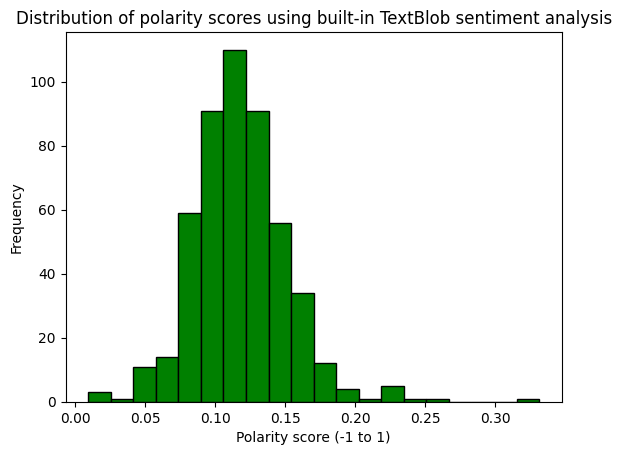

In [16]:
# use matplotlib to show the distribution of polarity scores
import matplotlib.pyplot as plt

# create histogram with green bars based on the values in the polarity column
plt.hist(polarity_df["polarity"], bins=20, edgecolor='black', color='green')
# title
plt.title("Distribution of polarity scores using built-in TextBlob sentiment analysis")
# xaxis label
plt.xlabel("Polarity score (-1 to 1)")
# yaxis label
plt.ylabel("Frequency")
# show the chart
plt.show()


In [17]:
print(polarity_df[polarity_df['manifesto_id'] == "181320_201905"]["text"])

3318    FIX SOUTH AFRICA TO CREATE A GOOD LIFE FOR EVE...
Name: text, dtype: str


## Sentiment analysis using supervised classification 

First, I need to output a csv with a random sample of 100 sentences from the documents in this corpus.

In [18]:
import random

# pick a random seed 
random.seed(47)

# extract sentences from all documents
all_sentences = []
for i, text in enumerate(mp_english["text"]):
    blob = TextBlob(str(text))
    manifesto_id = mp_english["manifesto_id"].iloc[i]
    for sent in blob.sentences:
        all_sentences.append({
            "manifesto_id": manifesto_id,
            "sentence": str(sent).strip()
        })

# create a dataframe with all sentences
sentences_df = pd.DataFrame(all_sentences)

# filter to sentences between 10 and 50 words so we exclude short fragments and extra long sentences
sentences_df = sentences_df[
    sentences_df["sentence"].str.split().str.len().between(10, 50)
]
# create a sample of 100 sentences to manually classify in google sheets
sample_df = sentences_df.sample(100, random_state=47).reset_index(drop=True)

# intitialize an empty column where i will manually input the sentiment
sample_df["label"] = "" 

# create output folder if it doesn't exist
os.makedirs("output/", exist_ok=True)

# save the random sample of sentences to a csv in the output folder
sample_df.to_csv("output/sentences_to_label.csv", index=False, encoding="utf-8")

In [19]:
# now after manually labeling the sentences, i'm going to re-read the sheet with all the sentiment labels
labeled_sentences = pd.read_csv("labeled_sentiments_sample - sentences_to_label.csv")
print(labeled_sentences["label"].value_counts())  # check distribution in sample


label
pos    46
neu    31
neg    23
Name: count, dtype: int64


In [20]:
from textblob.classifiers import NaiveBayesClassifier
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words('english'))

def word_features(text):
    tokens = word_tokenize(str(text))
    return {word.lower(): True for word in tokens if word.lower() not in stop_words and word.isalpha()}

# convert to textblob training format
train_data = list(zip(labeled_sentences["sentence"], labeled_sentences["label"]))

# split into train (80%) and test (20%)
split = int(len(train_data) * 0.8)
train = train_data[:split]
test  = train_data[split:]

# train with stopword-filtered features
cl = NaiveBayesClassifier(train, feature_extractor=word_features)

# evaluate
print(f"accuracy: {cl.accuracy(test):.2f}")
cl.show_informative_features(15)


accuracy: 0.25
Most Informative Features
              government = True              neg : pos    =      4.5 : 1.0
                american = True              neg : pos    =      4.2 : 1.0
                 attacks = True              neg : pos    =      4.2 : 1.0
                  canada = True              neg : pos    =      4.2 : 1.0
               including = True              neg : pos    =      4.2 : 1.0
                   party = True              neg : pos    =      4.2 : 1.0
                   years = True              neg : pos    =      4.2 : 1.0
               australia = True              neu : pos    =      3.5 : 1.0
                families = True              neu : pos    =      3.5 : 1.0
                    year = True              neu : pos    =      3.5 : 1.0
             communities = True              neg : neu    =      2.8 : 1.0
                  system = True              neg : neu    =      2.8 : 1.0
                agencies = True              neg : pos    =

In [21]:
def analyze_document(text, classifier):
    blob = TextBlob(str(text))

    scores = []
    for sent in blob.sentences:
        if len(str(sent).split()) < 4:  # skip very short fragments
            continue
        prob_dist = classifier.prob_classify(sent)
        # weighted score: pos=+1, neu=0, neg=-1
        score = prob_dist.prob("pos") * 1 + prob_dist.prob("neu") * 0 + prob_dist.prob("neg") * -1
        scores.append(score)

    if not scores:
        return {"mean_score": 0.0, "std_score": 0.0, "n_sentences": 0}

    return {
        "mean_score":   round(np.mean(scores), 4),
        "std_score":    round(np.std(scores), 4),
        "n_sentences":  len(scores),
    }


In [22]:
# classify the sentiment of the rest of the corpus using the NaiveBayes classifier
# this takes like six minutes to run 
results = []
for i, row in mp_english.iterrows():
    result = analyze_document(row["text"], cl)
    results.append({
        "manifesto_id": row["manifesto_id"],
        "party":        row["party"],
        "date":         row["date"],
        "text":         row["text"],
        "mean_score":   result["mean_score"],
        "std_score":    result["std_score"],
        "n_sentences":  result["n_sentences"],
    })

classified_df = pd.DataFrame(results)
print(classified_df.head(10))
print(classified_df["mean_score"].describe())
classified_df.to_csv("manifesto_classified.csv", index=False, encoding="utf-8")


   manifesto_id  party    date  \
0  31320_198106  31320  198106   
1  51320_196410  51320  196410   
2  51420_196410  51420  196410   
3  51620_196410  51620  196410   
4  51320_196603  51320  196603   
5  51420_196603  51420  196603   
6  51620_196603  51620  196603   
7  51320_197006  51320  197006   
8  51420_197006  51420  197006   
9  51620_197006  51620  197006   

                                                text  mean_score  std_score  \
0  François Mitterand's 110 Propositions for Fran...      0.1781     0.4250   
1  "THE NEW BRITAIN"  The world wants it and woul...      0.0406     0.4961   
2  "THINK FOR YOURSELF"  The Liberal Party offers...     -0.0260     0.4794   
3  "PROSPERITY WITH A PURPOSE"  Foreward  by Sir ...      0.0572     0.4854   
4  Time for Decision  PREFACE: TIME FOR DECISION ...      0.0755     0.4778   
5  For All the People: the Liberal Plan of 1966  ...      0.0166     0.4543   
6  Action Not Words: The New Conservative Program...      0.1385     0.4

In [23]:
classified_df.sort_values("mean_score", ascending=False).head(10)

,manifesto_id,party,date,text,mean_score,std_score,n_sentences
448,64320_202010,64320,202010,A STRONG RECOVERY FOR ALL These are uncertain ...,0.3298,0.4773,443
104,53620_198202,53620,198202,1. To give the country a stable government and...,0.2689,0.4459,12
439,64621_201409,64621,201409,INTRODUCTION TO NEW ZEALAND FIRST POLICIES BAC...,0.2592,0.4973,1392
390,64620_199010,64620,199010,The one thing virtually every New Zealander ag...,0.2488,0.4606,421
381,64620_198111,64620,198111,It’s people that really matter. “Our ability ...,0.2461,0.4551,1561
445,64621_201709,64621,201709,TRANSPORT “New Zealand First will ensure devel...,0.2456,0.4790,629
405,64620_199911,64620,199911,How would you write the next chapter of the Ne...,0.2370,0.4611,161
386,64320_198708,64320,198708,Labour's plan for the future INTRODUCTION BY ...,0.2365,0.5639,109
411,64422_200207,64422,200207,Ambitions for New Zealand. Progressive Coaliti...,0.2337,0.5016,92
206,62320_196304,62320,196304,A Canadian Development Fund to build up our re...,0.2271,0.3216,15


In [24]:
classified_df.sort_values("mean_score", ascending=True).head(10)

,manifesto_id,party,date,text,mean_score,std_score,n_sentences
415,64420_200509,64420,200509,Do you want a change in government? Tax cuts n...,-0.4077,0.4254,3
93,53320_197302,53320,197302,STATEMENT OF INTENT. THERE IS AN ALTERNATIVE ...,-0.3768,0.4874,38
94,53520_197302,53520,197302,STATEMENT OF INTENT. THERE IS AN ALTERNATIVE ...,-0.3768,0.4874,38
219,62620_197210,62620,197210,More than half of the bills brought by r Trude...,-0.3269,0.4950,70
137,53110_200705,53110,200705,Section 1: A Vibrant Green Economy Energy The ...,-0.3251,0.5893,343
231,62621_199706,62621,199706,“A FRESH START FOR CANADIANS” WE'LL REDUCE...,-0.3220,0.4869,38
490,181510_201905,181510,201905,The ACDP has identified 7 giants we believe st...,-0.2973,0.6879,16
182,61320_198811,61320,198811,"""The Restoration of Competence and the Revival...",-0.2679,0.6962,69
213,62951_196511,62951,196511,Social Credit presents an adequate and realist...,-0.2561,0.4897,69
422,64421_200811,64421,200811,PETER DUNNE United Future A PARTY vote for Uni...,-0.2467,0.4430,15


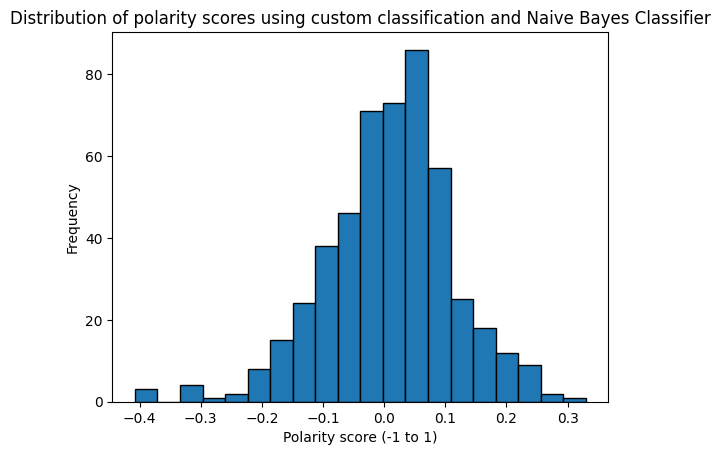

In [25]:
# create histogram with green bars based on the values in the polarity column
plt.hist(classified_df["mean_score"], bins=20, edgecolor='black')
# title
plt.title("Distribution of polarity scores using custom classification and Naive Bayes Classifier")
# xaxis label
plt.xlabel("Polarity score (-1 to 1)")
# yaxis label
plt.ylabel("Frequency")
# show the chart
plt.show()

In [26]:
print("Mean polarity:", classified_df["mean_score"].mean())
print("Median polarity:", classified_df["mean_score"].median())
print("Minimum polarity:", classified_df["mean_score"].min())
print("Maximum polarity:", classified_df["mean_score"].max())

Mean polarity: 0.008525050505050508
Median polarity: 0.0121
Minimum polarity: -0.4077
Maximum polarity: 0.3298


## look at changes in sentiment by party family 

In [27]:
# load party family mapping
parfam_df = pd.read_csv("party_families.csv")                                                      
   
# merge into classified_df                                                                         
merged_df = classified_df.merge(parfam_df, on="party", how="left")
                                                                                                     
# parse date: 196009 → 1960                                                                        
merged_df["year"] = merged_df["date"].astype(str).str[:4].astype(int)                              
                                                                                                     
# group by party family and year
trend_df = merged_df.groupby(["parfam", "year"])["mean_score"].mean().reset_index() 

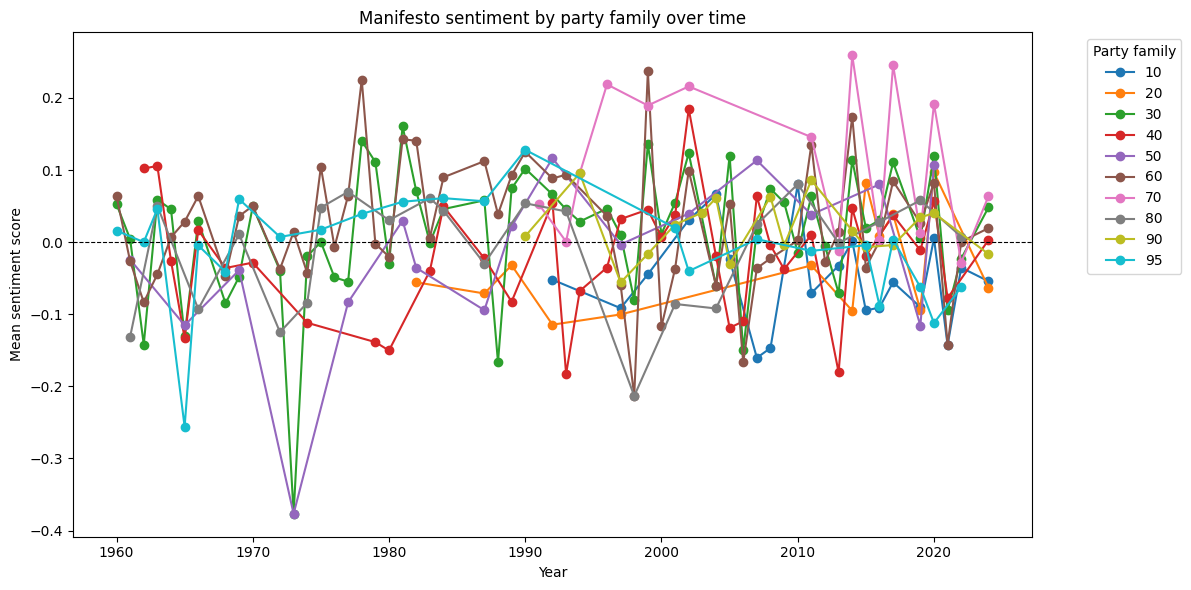

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

for parfam, group in trend_df.groupby("parfam"):
    ax.plot(group["year"], group["mean_score"], marker="o", label=parfam)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Year")
ax.set_ylabel("Mean sentiment score")
ax.set_title("Manifesto sentiment by party family over time")
ax.legend(title="Party family", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
